# 1. Problem Statement

Predict whether a student will Pass or Fail based on:

Attendance Percentage
Homework Percentage
Midterm Score
Study Hours Per Week
Target Variable
pass
Type of Problem

Since the output is:

Pass = 1
Fail = 0

It is a Classification Problem.



# 2.Data Gathering

Possible sources:

Kaggle
GitHub
Hugging Face Datasets
Educational Institution Records
Government Education Portals

Link - https://www.kaggle.com/datasets/ishanjha100/student-passfail-data


# 3. Data Loading
Import Libraries
import pandas as pd
import numpy as np
Load Dataset
data = pd.read_csv("Pass-Fail Data.csv")


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
data = pd.read_csv("Pass-Fail Data.csv")

# 4. Exploratory Data Analysis (EDA)


In [4]:
#Understanding about the data we have, for that we will apply  
data.head() # top 5 rows 


,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0


In [5]:
data.tail(3)# bottom 3 rows  


,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
97,98,55,56,58,5,0
98,99,91,90,88,12,1
99,100,52,50,53,4,0


In [6]:
data.info() # data types and non null counts 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   student_id            100 non-null    int64
 1   attendance_pct        100 non-null    int64
 2   homework_pct          100 non-null    int64
 3   midterm_score         100 non-null    int64
 4   study_hours_per_week  100 non-null    int64
 5   pass                  100 non-null    int64
dtypes: int64(6)
memory usage: 4.8 KB


In [7]:
data.describe() # summary statistics of numerical columns 


,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
count,100.000000,100.000000,100.00000,100.000000,100.00000,100.000000
mean,50.500000,69.520000,69.03000,68.780000,7.28000,0.600000
std,29.011492,17.651783,17.01304,14.717254,3.62115,0.492366
min,1.000000,30.000000,35.00000,42.000000,2.00000,0.000000
25%,25.750000,55.000000,55.00000,56.000000,4.00000,0.000000
50%,50.500000,72.500000,70.00000,68.000000,7.00000,1.000000
75%,75.250000,85.000000,85.00000,82.000000,10.00000,1.000000
max,100.000000,95.000000,96.00000,97.000000,15.00000,1.000000


In [8]:
data.describe(include='all') # summary statistics of all columns  , you can add include='object' to get summary of only categorical columns 


,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
count,100.000000,100.000000,100.00000,100.000000,100.00000,100.000000
mean,50.500000,69.520000,69.03000,68.780000,7.28000,0.600000
std,29.011492,17.651783,17.01304,14.717254,3.62115,0.492366
min,1.000000,30.000000,35.00000,42.000000,2.00000,0.000000
25%,25.750000,55.000000,55.00000,56.000000,4.00000,0.000000
50%,50.500000,72.500000,70.00000,68.000000,7.00000,1.000000
75%,75.250000,85.000000,85.00000,82.000000,10.00000,1.000000
max,100.000000,95.000000,96.00000,97.000000,15.00000,1.000000


In [9]:
data.shape # number of rows and columns 


(100, 6)

In [10]:
data.isnull().sum() # count of missing values in each column 

student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64

# Data Visualization

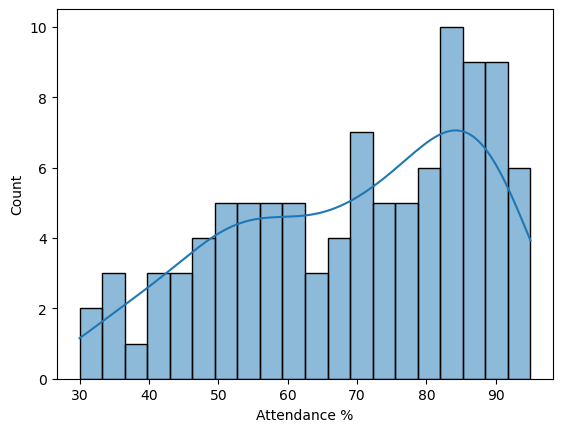

In [11]:
#Histogram
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data['attendance_pct'],
             bins=20,
             kde=True)

plt.xlabel("Attendance %")
plt.ylabel("Count")
plt.show()

<Axes: ylabel='attendance_pct'>

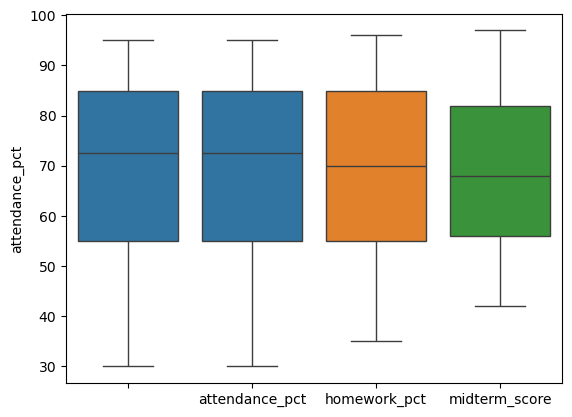

In [12]:
#Boxplot
sns.boxplot(data['attendance_pct'])
#Multiple Columns
sns.boxplot(
    data[['attendance_pct',
          'homework_pct',
          'midterm_score']]
)


<Axes: xlabel='pass', ylabel='count'>

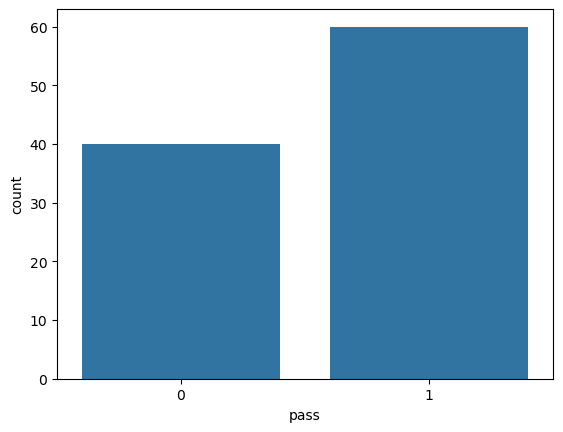

In [13]:
#Count Plot
sns.countplot(x='pass', data=data)


<Axes: xlabel='study_hours_per_week', ylabel='midterm_score'>

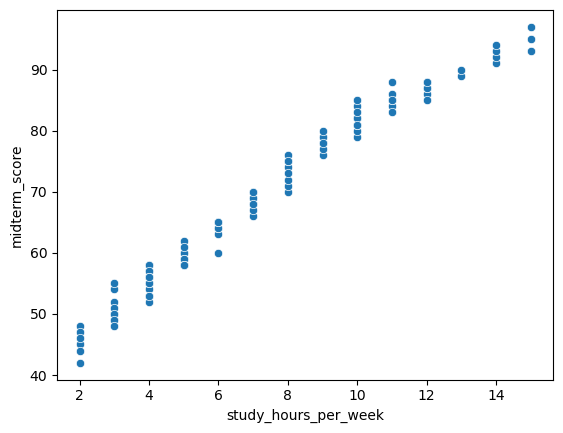

In [14]:
#Scatter Plot
sns.scatterplot(
    x='study_hours_per_week',
    y='midterm_score',
    data=data
)


<Axes: >

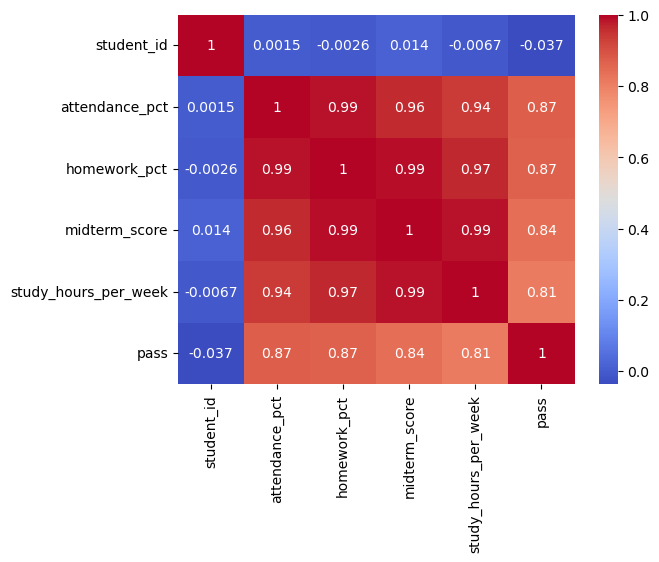

In [15]:
#Correlation Heatmap
corr = data.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')


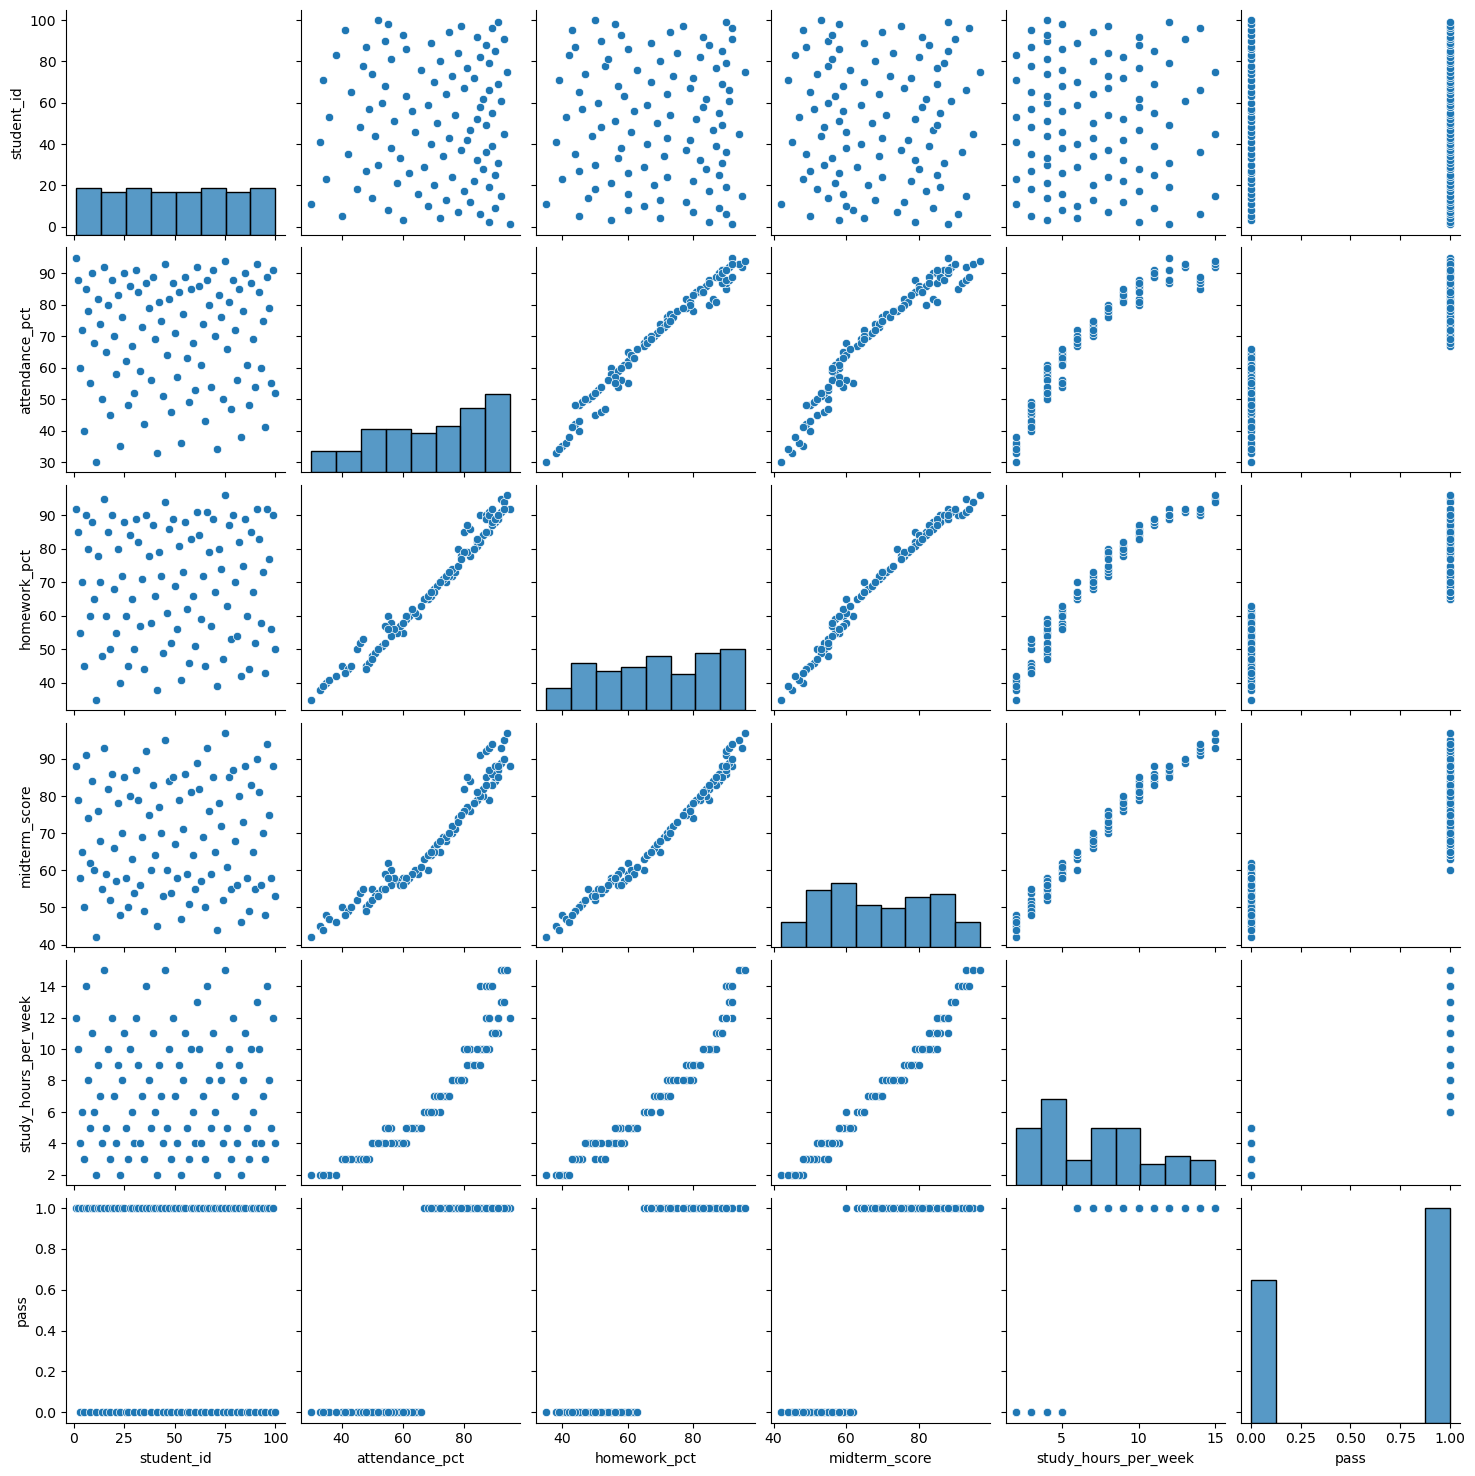

In [16]:
#Pair Plot
sns.pairplot(data)

# 5. Data Preprocessing

In [17]:
#headling with null values
data.isnull().sum() # count of missing values in each column

student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64

In [18]:
#Checking for duplicates
data.duplicated().sum() # count of duplicate rows

np.int64(0)

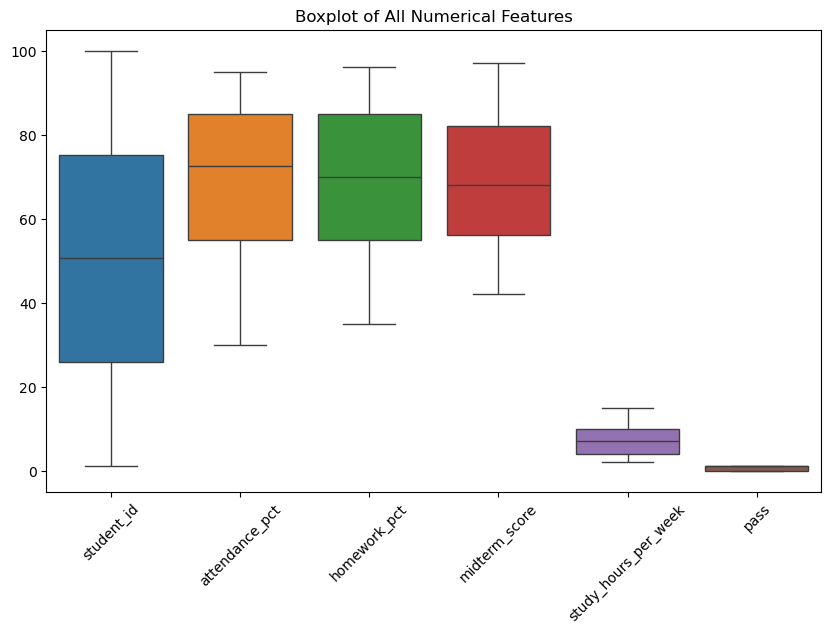

In [19]:
#Observing the outliers in the data
plt.figure(figsize=(10, 6))
sns.boxplot(data)
plt.xticks(rotation=45)
plt.title("Boxplot of All Numerical Features")
plt.show()
#there are no outliers in the data as all the values are within thef the boxplot.

In [20]:
#if there were outliers, we could have used the IQR method to remove them. Here's how you can do it:
# IQR method to remove outliers
def remove_outliers_iqr(data, x):
    q1 = np.quantile(data[x], 0.25)
    q3 = np.quantile(data[x], 0.75)
    iqr = q3 - q1
    
    lowest_value = q1 - 1.5 * iqr
    highest_value = q3 + 1.5 * iqr
    
    filtered_data = data[(data[x] > lowest_value) & (data[x] < highest_value)]
    
    print("Removing outliers completed...")
    sns.boxplot(data[x])
    return filtered_data

In [21]:
#Remove Unwanted Columns
#Student ID does not help prediction.

data.drop(
    ['student_id'],
    axis=1,
    inplace=True
)

# 6. Feature Engineering

In your dataset all features are already numerical:

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features = [
    'attendance_pct',
    'homework_pct',
    'midterm_score',
    'study_hours_per_week'
]

data[features] = scaler.fit_transform(
    data[features]
)

# 7. Developing model 

In [24]:
#Splitting Features and Target
X = data.drop('pass', axis=1)
y = data['pass']

In [30]:
#checking the shapes of the features and target
X.shape, y.shape 

((100, 4), (100,))

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#checking the shapes of the train and test sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 4), (20, 4), (80,), (20,))

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

# Prediction


In [32]:
y_pred = model.predict(X_test)

# Performance Evaluation



In [33]:
#Since this is a Classification Problem:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [34]:
#Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)


1.0


In [35]:
#precision
precision = precision_score(
    y_test,
    y_pred
)
print(precision)


1.0


In [36]:
#Recall
recall = recall_score(
    y_test,
    y_pred
)
print(recall)


1.0


In [37]:
#F1 Score
f1 = f1_score(
    y_test,
    y_pred
)
print(f1)


1.0


In [38]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)


[[ 8  0]
 [ 0 12]]


In [39]:
#Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



# Save Model

In [40]:

import pickle
with open(
    "pass_fail_model.pkl",
    "wb") as file:

    pickle.dump(
        model,file)

# prediction

In [45]:
import pickle
import pandas as pd

# Load trained model
with open("pass_fail_model.pkl", "rb") as file:
    model = pickle.load(file)

# New student data
new_student = pd.DataFrame({
    "attendance_pct": [85],
    "homework_pct": [80],
    "midterm_score": [75],
    "study_hours_per_week": [8]
})

# Predict
prediction = model.predict(new_student)

# Display result
if prediction[0] == 1:
    print("Student will PASS")
else:
    print("Student will FAIL")

Student will PASS
